# Profit Prediction — Regression Project


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone


In [2]:

sns.set_style("whitegrid")
%matplotlib inline

PRIMARY = "#4C72B0"   
SECONDARY = "#DD8452"   
PALETTE = "deep"       
MEAN_COLOR = "#C0392B" 
MEDIAN_COLOR = "#2E7D32"  

plt.rcParams.update({
    "figure.dpi": 100,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "font.size": 10,
})


## 2. Load and Merge Data

In [3]:
customer = pd.read_csv("customer.csv")
orders = pd.read_csv("order.csv")
order_detail = pd.read_csv("order_detail.csv")
returned = pd.read_csv("returned.csv")
shipping = pd.read_csv("shipping.csv")
product = pd.read_csv("product.csv")



In [4]:
print("customer:", customer.shape)
print("orders:", orders.shape)
print("order_detail:", order_detail.shape)
print("returned:", returned.shape)
print("shipping:", shipping.shape)
print("product:", product.shape)


customer: (924, 3)
orders: (25033, 5)
order_detail: (49670, 8)
returned: (1172, 1)
shipping: (25033, 8)
product: (10246, 4)


### 2.0.1 Inspect Raw Tables
Before merging, we look at each table separately with `head` and `describe`.

In [5]:
customer.head()

,Customer ID,Customer Name,Segment
0,AA-10315,Alex Avila,Consumer
1,AA-10375,Allen Armold,Consumer
2,AA-10480,Andrew Allen,Consumer
3,AA-10645,Anna Andreadi,Consumer
4,AB-10015,Aaron Bergman,Consumer


In [6]:
orders.head()

,Order ID,Customer ID,Order Priority,Order Date,Market
0,AE-2011-9160,PO-18865,Medium,2011-10-03 00:00:00,EMEA
1,AE-2013-1130,EB-14110,High,2013-10-14 00:00:00,EMEA
2,AE-2013-1530,MY-17380,High,2013-12-31 00:00:00,EMEA
3,AE-2014-2840,PG-18820,Critical,2014-11-05 00:00:00,EMEA
4,AE-2014-3830,GH-14665,Medium,2014-12-13 00:00:00,EMEA


In [7]:
order_detail.head()

,Row ID,Order ID,Product ID,Sales,Quantity,Discount,Profit,Shipping Cost
0,1,MX-2014-143658,OFF-LA-10002782,13.08,3,0.0,4.56,1.033
1,2,MX-2012-155047,FUR-FU-10004015,252.16,8,0.0,90.72,13.449
2,3,MX-2012-155047,FUR-BO-10002352,193.28,2,0.0,54.08,9.627
3,4,MX-2012-155047,OFF-BI-10004428,35.44,4,0.0,4.96,1.371
4,5,MX-2012-155047,OFF-AR-10004594,71.60,2,0.0,11.44,3.787


In [8]:
product.head()

,Product ID,Product Name,Category,Sub-Category
0,FUR-ADV-10000002,"Advantus Photo Frame, Duo Pack",Furniture,Furnishings
1,FUR-ADV-10000108,"Advantus Clock, Erganomic",Furniture,Furnishings
2,FUR-ADV-10000183,"Advantus Photo Frame, Black",Furniture,Furnishings
3,FUR-ADV-10000188,"Advantus Stacking Tray, Erganomic",Furniture,Furnishings
4,FUR-ADV-10000190,"Advantus Frame, Duo Pack",Furniture,Furnishings


In [9]:
returned.head()

,Order ID
0,CA-2011-100762
1,CA-2011-100867
2,CA-2011-102652
3,CA-2011-103373
4,CA-2011-103744


In [10]:
shipping.head()

,Shipping ID,Order ID,Ship Date,Ship Mode,City,State,Country,Region
0,21043,CA-2012-124891,2012-07-31 00:00:00,Same Day,New York City,New York,United States,East
1,21044,IN-2013-77878,2013-02-07 00:00:00,Second Class,Wollongong,New South Wales,Australia,Oceania
2,21045,IN-2013-71249,2013-10-18 00:00:00,First Class,Brisbane,Queensland,Australia,Oceania
3,21046,ES-2013-1579342,2013-01-30 00:00:00,First Class,Berlin,Berlin,Germany,Central
4,21047,SG-2013-4320,2013-11-06 00:00:00,Same Day,Dakar,Dakar,Senegal,Africa


In [11]:
customer.describe()

,Customer ID,Customer Name,Segment
count,924,924,924
unique,924,795,3
top,AA-10315,Zuschuss Donatelli,Consumer
freq,1,2,476


In [12]:
orders.describe()

,Order ID,Customer ID,Order Priority,Order Date,Market
count,25033,25033,25033,25033,25033
unique,25033,924,4,1428,7
top,AE-2011-9160,FO-14305,Medium,2014-11-25 00:00:00,APAC
freq,1,46,14344,59,5437


In [13]:
order_detail.describe()

,Row ID,Sales,Quantity,Discount,Profit,Shipping Cost
count,49670.000000,49670.000000,49670.000000,49670.000000,49670.000000,49670.000000
mean,25763.380974,243.840355,3.470787,0.143070,28.392264,26.041125
std,14838.084164,485.963091,2.274854,0.212046,172.399520,56.870281
min,1.000000,0.444000,1.000000,0.000000,-6599.980000,0.002000
25%,12749.250000,30.384000,2.000000,0.000000,0.000000,2.580000
50%,26073.500000,83.970000,3.000000,0.000000,9.154000,7.660000
75%,38522.750000,247.830000,5.000000,0.200000,36.266400,23.969000
max,51290.000000,22638.500000,14.000000,0.850000,8399.980000,933.570000


In [14]:
product.describe()

,Product ID,Product Name,Category,Sub-Category
count,10246,10246,10246,10246
unique,10246,3662,3,17
top,FUR-ADV-10000002,Staples,Office Supplies,Paper
freq,1,45,5674,779


In [15]:
returned.describe()

,Order ID
count,1172
unique,1172
top,CA-2011-100762
freq,1


In [16]:
shipping.describe(include='all')

,Shipping ID,Order ID,Ship Date,Ship Mode,City,State,Country,Region
count,25033.00000,25033,25033,25033,25033,25033,25033,25033
unique,NaN,25033,1464,4,3590,1089,147,13
top,NaN,CA-2012-124891,2014-11-17 00:00:00,Standard Class,New York City,California,United States,Central
freq,NaN,1,54,15011,448,1016,4990,5238
mean,33559.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,7226.54898,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,21043.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,27301.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,33559.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,39817.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.0 Fix Duplicate Customer Names
Some customers have several different Customer IDs. We unify the IDs so one customer's info isn't split up.

In [17]:
n_dup_names = customer["Customer Name"].duplicated().sum()
print("duplicated name in customer name:", n_dup_names)
canonical_lookup = customer.groupby("Customer Name")["Customer ID"].first().to_dict()
id_to_name = customer.set_index("Customer ID")["Customer Name"].to_dict()
id_to_canonical = {cid: canonical_lookup[name] for cid, name in id_to_name.items()}

orders["Customer ID"] = orders["Customer ID"].map(id_to_canonical).fillna(orders["Customer ID"])
customer = customer.drop_duplicates(subset=["Customer Name"], keep="first")

print("duplicated row after dropping", customer.shape[0])


duplicated name in customer name: 129
duplicated row after dropping 795


In [18]:
df = order_detail.merge(orders, on="Order ID", how="left")
df = df.merge(customer, on="Customer ID", how="left")
df = df.merge(shipping, on="Order ID", how="left")
df = df.merge(product[["Product ID", "Category", "Sub-Category"]], on="Product ID", how="left")

returned["Returned"] = 1
df = df.merge(returned[["Order ID", "Returned"]], on="Order ID", how="left")
df["Returned"] = df["Returned"].fillna(0)

df.head()


,Row ID,Order ID,Product ID,Sales,Quantity,Discount,Profit,Shipping Cost,Customer ID,Order Priority,...,Shipping ID,Ship Date,Ship Mode,City,State,Country,Region,Category,Sub-Category,Returned
0,1,MX-2014-143658,OFF-LA-10002782,13.08,3,0.0,4.56,1.033,SC-10575,Medium,...,44634,2014-10-06 00:00:00,Standard Class,Mexico City,Distrito Federal,Mexico,North,Office Supplies,Labels,0.0
1,2,MX-2012-155047,FUR-FU-10004015,252.16,8,0.0,90.72,13.449,KW-16570,Medium,...,34096,2012-10-20 00:00:00,Standard Class,Dos Quebradas,Risaralda,Colombia,South,Furniture,Furnishings,0.0
2,3,MX-2012-155047,FUR-BO-10002352,193.28,2,0.0,54.08,9.627,KW-16570,Medium,...,34096,2012-10-20 00:00:00,Standard Class,Dos Quebradas,Risaralda,Colombia,South,Furniture,Bookcases,0.0
3,4,MX-2012-155047,OFF-BI-10004428,35.44,4,0.0,4.96,1.371,KW-16570,Medium,...,34096,2012-10-20 00:00:00,Standard Class,Dos Quebradas,Risaralda,Colombia,South,Office Supplies,Binders,0.0
4,5,MX-2012-155047,OFF-AR-10004594,71.60,2,0.0,11.44,3.787,KW-16570,Medium,...,34096,2012-10-20 00:00:00,Standard Class,Dos Quebradas,Risaralda,Colombia,South,Office Supplies,Art,0.0


In [19]:
df["Row ID"].unique()


array([    1,     2,     3, ..., 51288, 51289, 51290], shape=(49670,))

In [20]:
df.drop(columns="Row ID", inplace=True)


In [21]:
df.shape

(49670, 23)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49670 entries, 0 to 49669
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        49670 non-null  object 
 1   Product ID      49670 non-null  object 
 2   Sales           49670 non-null  float64
 3   Quantity        49670 non-null  int64  
 4   Discount        49670 non-null  float64
 5   Profit          49670 non-null  float64
 6   Shipping Cost   49670 non-null  float64
 7   Customer ID     49670 non-null  object 
 8   Order Priority  49670 non-null  object 
 9   Order Date      49670 non-null  object 
 10  Market          49670 non-null  object 
 11  Customer Name   49670 non-null  object 
 12  Segment         49670 non-null  object 
 13  Shipping ID     49670 non-null  int64  
 14  Ship Date       49670 non-null  object 
 15  Ship Mode       49670 non-null  object 
 16  City            49670 non-null  object 
 17  State           49670 non-null 

### 2.1.1 Optimize dtypes
Categorical columns become `category` and numeric columns get lighter types. This doesn't change the results, it just reduces memory usage.

In [23]:
df = df.astype({
    "Quantity": "int8",
    "Shipping ID": "int32",
    "Sales": "float32",
    "Discount": "float32",
    "Profit": "float32",
    "Shipping Cost": "float32",
    "Returned": "int8",
})

category_dict = {
    "Order Priority": "category",
    "Market": "category",
    "Category": "category",
    "Sub-Category": "category",
    "Segment": "category",
    "Ship Mode": "category",
    "City": "category",
    "State": "category",
    "Country": "category",
    "Region": "category",
}

df = df.astype(category_dict)

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49670 entries, 0 to 49669
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Order ID        49670 non-null  object  
 1   Product ID      49670 non-null  object  
 2   Sales           49670 non-null  float32 
 3   Quantity        49670 non-null  int8    
 4   Discount        49670 non-null  float32 
 5   Profit          49670 non-null  float32 
 6   Shipping Cost   49670 non-null  float32 
 7   Customer ID     49670 non-null  object  
 8   Order Priority  49670 non-null  category
 9   Order Date      49670 non-null  object  
 10  Market          49670 non-null  category
 11  Customer Name   49670 non-null  object  
 12  Segment         49670 non-null  category
 13  Shipping ID     49670 non-null  int32   
 14  Ship Date       49670 non-null  object  
 15  Ship Mode       49670 non-null  category
 16  City            49670 non-null  category
 17  State       

In [24]:
df.describe(include="object")

,Order ID,Product ID,Customer ID,Order Date,Customer Name,Ship Date
count,49670,49670,49670,49670,49670,49670
unique,25033,10246,795,1428,795,1464
top,CA-2014-100111,OFF-AR-10003651,SW-10755,2014-09-03 00:00:00,Steven Ward,2014-11-22 00:00:00
freq,14,32,104,125,104,125


In [25]:
df.describe()

,Sales,Quantity,Discount,Profit,Shipping Cost,Shipping ID,Returned
count,49670.000000,49670.000000,49670.000000,49670.000000,49670.000000,49670.000000,49670.000000
mean,243.840347,3.470787,0.143070,28.392263,26.041124,31632.081639,0.059996
std,485.960907,2.274854,0.212061,172.398849,56.870155,6964.662856,0.237482
min,0.444000,1.000000,0.000000,-6599.979980,0.002000,21043.000000,0.000000
25%,30.384001,2.000000,0.000000,0.000000,2.580000,25564.000000,0.000000
50%,83.970001,3.000000,0.000000,9.154000,7.660000,30862.000000,0.000000
75%,247.829998,5.000000,0.200000,36.266400,23.968999,37182.750000,0.000000
max,22638.500000,14.000000,0.850000,8399.980469,933.570007,46075.000000,1.000000


### 2.2 Numeric and Categorical Column Lists
Defined once here and reused across the EDA and statistical-test sections below.


In [26]:
numeric_columns = ["Sales", "Quantity", "Discount", "Profit", "Shipping Cost"]

categorical_columns = [
    "Order Priority", "Market", "Category", "Sub-Category",
    "Segment", "Ship Mode", "City", "State", "Country", "Region",
    "Returned",
]


## 3. Exploratory Data Analysis (EDA)

### 3.1 Check Missing Values

In [27]:
def nan_percentage(df: pd.DataFrame) -> pd.DataFrame:
    total_rows = len(df)
    missing_count = [df[col].isna().sum() for col in df.columns]
    nan_pct = [(df[col].isna().sum() / total_rows) * 100 for col in df.columns]
    result = pd.DataFrame({"Missing Count": missing_count, "Nan Percent": nan_pct}, index=df.columns)
    return result.sort_values(by="Nan Percent", ascending=False)


In [28]:
nan_percentage(df)


,Missing Count,Nan Percent
Order ID,0,0.0
Segment,0,0.0
Sub-Category,0,0.0
Category,0,0.0
Region,0,0.0
Country,0,0.0
State,0,0.0
City,0,0.0
Ship Mode,0,0.0
Ship Date,0,0.0


### 3.2 Check Duplicate Data

In [29]:
print("تعداد رکورد تکراری:", df.duplicated().sum())

تعداد رکورد تکراری: 0


### 3.3 Target Variable Distribution (Profit)

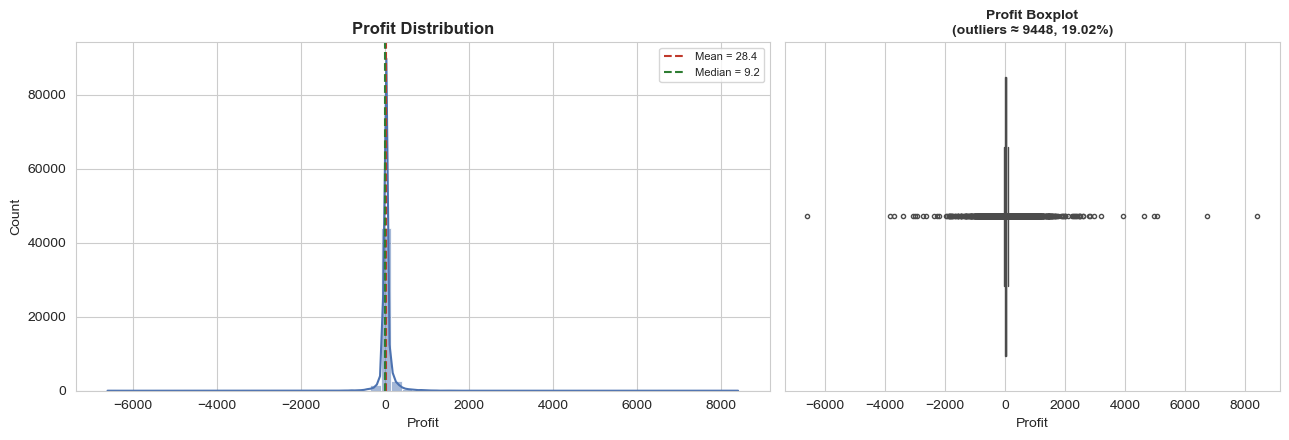

Skewness of Profit: 4.47


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [1.4, 1]})

p_mean = df["Profit"].mean()
p_median = df["Profit"].median()
q1, q3 = df["Profit"].quantile([0.25, 0.75])
iqr = q3 - q1
n_outliers = ((df["Profit"] < q1 - 1.5 * iqr) | (df["Profit"] > q3 + 1.5 * iqr)).sum()
pct_outliers = round(100 * n_outliers / len(df), 2)

sns.histplot(df["Profit"], bins=60, kde=True, color=PRIMARY, ax=axes[0])
axes[0].axvline(p_mean, color=MEAN_COLOR, linestyle="--", label=f"Mean = {p_mean:.1f}")
axes[0].axvline(p_median, color=MEDIAN_COLOR, linestyle="--", label=f"Median = {p_median:.1f}")
axes[0].set_title("Profit Distribution")
axes[0].set_xlabel("Profit")
axes[0].legend(fontsize=8)

sns.boxplot(x=df["Profit"], color=PRIMARY, ax=axes[1], fliersize=3)
axes[1].set_title(f"Profit Boxplot\n(outliers ≈ {n_outliers}, {pct_outliers}%)", fontsize=10)
axes[1].set_xlabel("Profit")

plt.tight_layout()
plt.show()

print(f"Skewness of Profit: {df['Profit'].skew():.2f}")


Profit isn't normally distributed and has some very large positive/negative values. This affects RMSE.

### 3.4 Check Outliers

In [31]:
Q1 = df["Profit"].quantile(0.25)
Q3 = df["Profit"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df["Profit"] < Q1 - 1.5 * IQR) | (df["Profit"] > Q3 + 1.5 * IQR)]
print("تعداد Outlierهای Profit:", outliers.shape[0])
print("درصد تقریبی:", round(outliers.shape[0] / len(df) * 100, 2))

تعداد Outlierهای Profit: 9448
درصد تقریبی: 19.02


### 3.5 Correlation Matrix

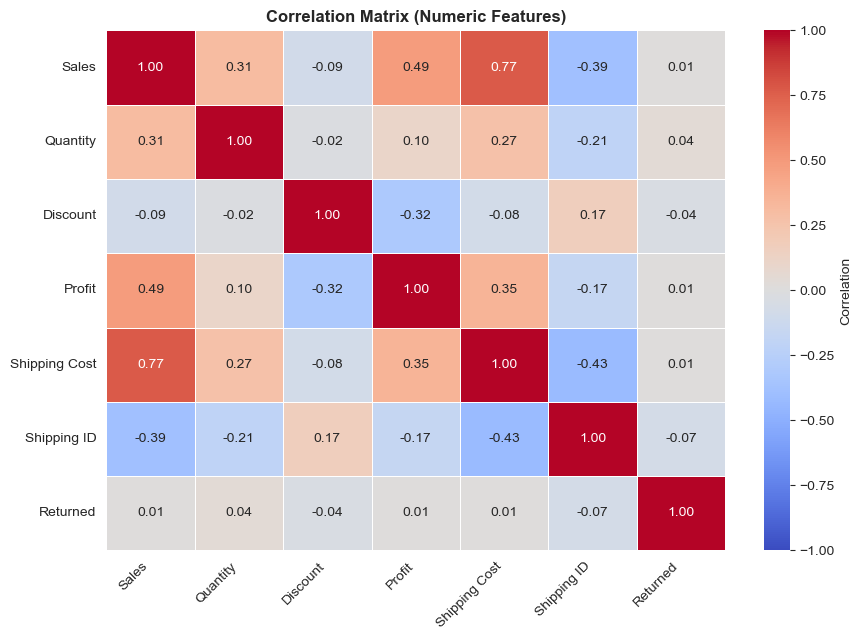

In [32]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(9, 6.5))
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f",
    cmap="coolwarm", vmin=-1, vmax=1, center=0,
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Correlation"}
)
plt.title("Correlation Matrix (Numeric Features)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### 3.6 Relationship Between Categorical Features and Profit

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_4148\2042473260.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=cat_col, y="Profit", order=order, palette=PALETTE, ax=ax, fliersize=2)
C:\Users\VICTUS\AppData\Local\Temp\ipykernel_4148\2042473260.py:7: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
C:\Users\VICTUS\AppData\Local\Temp\ipykernel_4148\2042473260.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=cat_col, y="Profit", order=order, palette=PALETTE, ax=ax, fliersize=2)
C:\Users\VIC

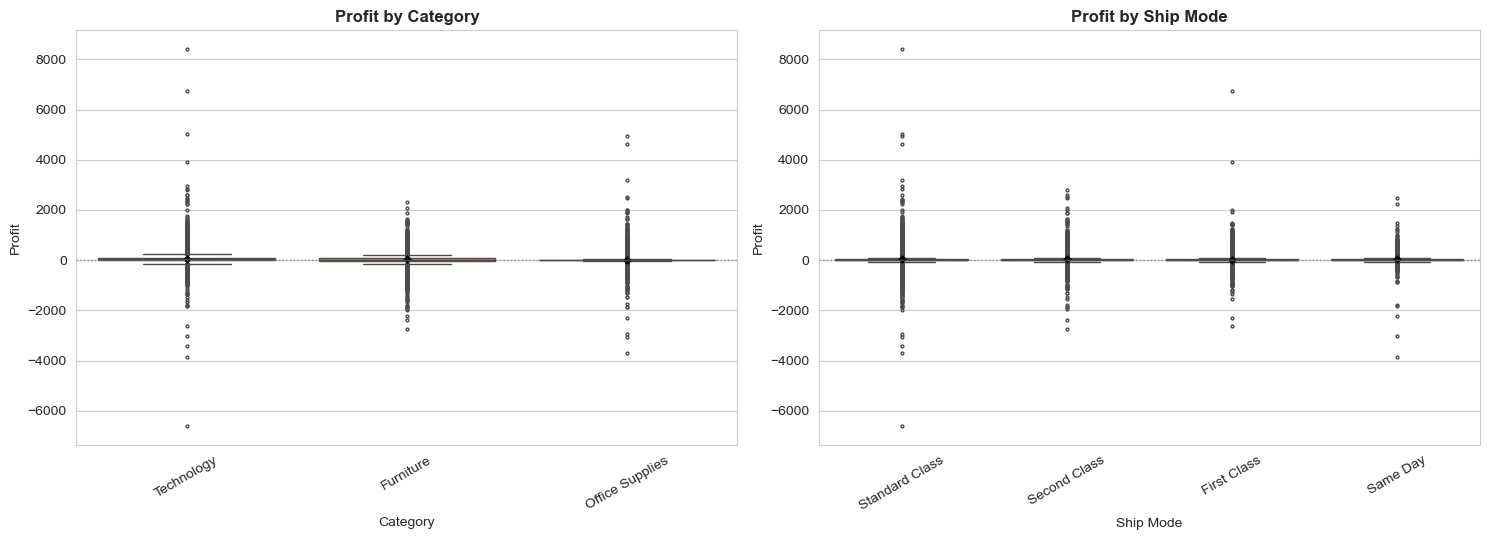

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for ax, cat_col in zip(axes, ["Category", "Ship Mode"]):
    order = df.groupby(cat_col, observed=True)["Profit"].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=cat_col, y="Profit", order=order, palette=PALETTE, ax=ax, fliersize=2)

    sns.pointplot(
        data=df, x=cat_col, y="Profit", order=order,
        color="black", markers="D", scale=0.6, errorbar=None, ax=ax, linestyle="none"
    )
    ax.set_title(f"Profit by {cat_col}")
    ax.tick_params(axis="x", rotation=30)
    ax.axhline(0, color="grey", linestyle=":", linewidth=1)

plt.tight_layout()
plt.show()


## 4. Data Preprocessing

### 4.1 Remove Duplicates and Missing Values

In [34]:
df = df.drop_duplicates()

df = df.dropna().copy()
print(df.shape)

(49670, 23)


### 4.2 Process Date Columns

In [35]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

df["Order Month"] = df["Order Date"].dt.month
df["Order Year"] = df["Order Date"].dt.year
df["Order DayOfWeek"] = df["Order Date"].dt.dayofweek
df["Shipping Duration"] = (df["Ship Date"] - df["Order Date"]).dt.days

df[["Order Date", "Ship Date", "Order Month", "Order Year", "Shipping Duration"]].head()

,Order Date,Ship Date,Order Month,Order Year,Shipping Duration
0,2014-10-02,2014-10-06,10,2014,4
1,2012-10-15,2012-10-20,10,2012,5
2,2012-10-15,2012-10-20,10,2012,5
3,2012-10-15,2012-10-20,10,2012,5
4,2012-10-15,2012-10-20,10,2012,5


### 4.3 Clip Extreme Outliers


In [36]:
cols_to_clip = ["Profit", "Sales", "Shipping Cost"]

for col in cols_to_clip:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    print(f"{col}: clipping to [{lower:.2f}, {upper:.2f}] (was [{df[col].min():.2f}, {df[col].max():.2f}])")
    df[col] = df[col].clip(lower, upper)

Profit: clipping to [-345.08, 582.40] (was [-6599.98, 8399.98])
Sales: clipping to [3.64, 2300.25] (was [0.44, 22638.50])
Shipping Cost: clipping to [0.20, 286.45] (was [0.00, 933.57])


## 5. Feature Engineering

In [37]:
print("تعداد City:", df["City"].nunique())
print("تعداد State:", df["State"].nunique())
print("تعداد Product ID:", df["Product ID"].nunique())
print("تعداد Sub-Category:", df["Sub-Category"].nunique())
print("تعداد Country:", df["Country"].nunique())
print("تعداد Region:", df["Region"].nunique())
print("تعداد Market:", df["Market"].nunique())


تعداد City: 3590
تعداد State: 1089
تعداد Product ID: 10246
تعداد Sub-Category: 17
تعداد Country: 147
تعداد Region: 13
تعداد Market: 7


In [38]:
drop_cols = [
    "Order ID",
    "Customer Name", "Shipping ID",
    "Order Date", "Ship Date"
]


df_model = df.drop(columns=drop_cols, errors="ignore")
df_model.columns.tolist()

['Product ID',
 'Sales',
 'Quantity',
 'Discount',
 'Profit',
 'Shipping Cost',
 'Customer ID',
 'Order Priority',
 'Market',
 'Segment',
 'Ship Mode',
 'City',
 'State',
 'Country',
 'Region',
 'Category',
 'Sub-Category',
 'Returned',
 'Order Month',
 'Order Year',
 'Order DayOfWeek',
 'Shipping Duration']

### 5.0.2 Target / Split (moved up)
The aggregate features built in 5.0.3 are grouped statistics (avg sale per customer, etc.). If they're built before splitting, train and test rows leak into each other's averages. So the split happens here, before any aggregation, and everything from this point on is fit on `X_train`/`y_train` only.

In [39]:
target_col = "Profit"

X = df_model.drop(columns=[target_col])
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (39736, 21)
Test: (9934, 21)


### 5.0.3 Customer / Product / Category / Location Aggregate Features


In [40]:
def add_group_features(train_df, other_df):
    train_df = train_df.copy()
    other_df = other_df.copy()

    group_specs = [
        ("Customer ID", {
            "cust_order_count": ("Customer ID", "count"),
            "cust_avg_sales": ("Sales", "mean"),
            "cust_avg_discount": ("Discount", "mean"),
            "cust_avg_quantity": ("Quantity", "mean"),
            "cust_return_rate": ("Returned", "mean"),
        }),
        ("Product ID", {
            "prod_avg_sales": ("Sales", "mean"),
            "prod_avg_discount": ("Discount", "mean"),
            "prod_total_qty": ("Quantity", "sum"),
            "prod_return_rate": ("Returned", "mean"),
        }),
        ("Category", {
            "cat_avg_sales": ("Sales", "mean"),
            "cat_avg_discount": ("Discount", "mean"),
        }),
        ("Sub-Category", {
            "subcat_avg_sales": ("Sales", "mean"),
            "subcat_avg_discount": ("Discount", "mean"),
            "subcat_return_rate": ("Returned", "mean"),
        }),
        ("Region", {
            "region_avg_sales": ("Sales", "mean"),
            "region_avg_shipping": ("Shipping Cost", "mean"),
            "region_avg_discount": ("Discount", "mean"),
            "region_return_rate": ("Returned", "mean"),
        }),
        ("Market", {
            "market_avg_sales": ("Sales", "mean"),
            "market_avg_discount": ("Discount", "mean"),
        }),
        ("Segment", {
            "segment_avg_sales": ("Sales", "mean"),
            "segment_avg_discount": ("Discount", "mean"),
        }),
        ("Ship Mode", {
            "shipmode_avg_shipping": ("Shipping Cost", "mean"),
            "shipmode_avg_discount": ("Discount", "mean"),
        }),
        ("City", {
            "city_avg_sales": ("Sales", "mean"),
            "city_avg_discount": ("Discount", "mean"),
            "city_avg_shipping": ("Shipping Cost", "mean"),
            "city_order_count": ("City", "count"),
        }),
        ("State", {
            "state_avg_sales": ("Sales", "mean"),
            "state_avg_discount": ("Discount", "mean"),
            "state_avg_shipping": ("Shipping Cost", "mean"),
        }),
    ]

    new_cols = []
    for key, agg_map in group_specs:
        stats = train_df.groupby(key, observed=True).agg(**agg_map).reset_index()
        train_df = train_df.merge(stats, on=key, how="left")
        other_df = other_df.merge(stats, on=key, how="left")
        new_cols += list(agg_map.keys())


    other_df[new_cols] = other_df[new_cols].fillna(train_df[new_cols].mean())

    return train_df, other_df, new_cols


X_train, X_test, group_feature_cols = add_group_features(X_train, X_test)
print("new aggregate features:", group_feature_cols)

new aggregate features: ['cust_order_count', 'cust_avg_sales', 'cust_avg_discount', 'cust_avg_quantity', 'cust_return_rate', 'prod_avg_sales', 'prod_avg_discount', 'prod_total_qty', 'prod_return_rate', 'cat_avg_sales', 'cat_avg_discount', 'subcat_avg_sales', 'subcat_avg_discount', 'subcat_return_rate', 'region_avg_sales', 'region_avg_shipping', 'region_avg_discount', 'region_return_rate', 'market_avg_sales', 'market_avg_discount', 'segment_avg_sales', 'segment_avg_discount', 'shipmode_avg_shipping', 'shipmode_avg_discount', 'city_avg_sales', 'city_avg_discount', 'city_avg_shipping', 'city_order_count', 'state_avg_sales', 'state_avg_discount', 'state_avg_shipping']


### 5.0.3b Snapshot for CatBoost (keeps IDs as native categoricals)


In [41]:

catboost_cat_cols = [
    "Customer ID", "Product ID", "City", "State",
    "Category", "Sub-Category", "Region", "Market", "Segment", "Ship Mode"
]

category_dtype_cols = X_train.select_dtypes(include=["category"]).columns.tolist()
for col in category_dtype_cols:
    if col not in catboost_cat_cols:
        catboost_cat_cols.append(col)

catboost_cat_cols = [c for c in catboost_cat_cols if c in X_train.columns]

X_train_cb = X_train.copy()
X_test_cb = X_test.copy()

for col in catboost_cat_cols:
    X_train_cb[col] = X_train_cb[col].astype(str)
    X_test_cb[col] = X_test_cb[col].astype(str)

print("CatBoost categorical columns:", catboost_cat_cols)
print("Pandas category columns included:", category_dtype_cols)


CatBoost categorical columns: ['Customer ID', 'Product ID', 'City', 'State', 'Category', 'Sub-Category', 'Region', 'Market', 'Segment', 'Ship Mode', 'Order Priority', 'Country']
Pandas category columns included: ['Order Priority', 'Market', 'Segment', 'Ship Mode', 'City', 'State', 'Country', 'Region', 'Category', 'Sub-Category']


### 5.0.4 Drop ID Columns


In [42]:
X_train = X_train.drop(columns=["Customer ID", "Product ID", "City", "State"])
X_test = X_test.drop(columns=["Customer ID", "Product ID", "City", "State"])

### 5.0.5 New Interaction Features


In [43]:
for part in (X_train, X_test):
    part["Sales_x_Discount"] = part["Sales"] * part["Discount"]
    part["Sales_after_Discount"] = part["Sales"] * (1 - part["Discount"])
    part["Unit_Price"] = part["Sales"] / part["Quantity"].replace(0, 1)

print("new column:", ["Sales_x_Discount", "Sales_after_Discount", "Unit_Price"])
X_train[["Sales", "Discount", "Sales_x_Discount", "Sales_after_Discount", "Unit_Price"]].head()

new column: ['Sales_x_Discount', 'Sales_after_Discount', 'Unit_Price']


,Sales,Discount,Sales_x_Discount,Sales_after_Discount,Unit_Price
0,579.450012,0.0,0.000000,579.450012,115.890002
1,244.768005,0.2,48.953602,195.814407,61.192001
2,21.719999,0.0,0.000000,21.719999,10.860000
3,13.380000,0.0,0.000000,13.380000,13.380000
4,13.110000,0.0,0.000000,13.110000,13.110000


### 5.1 Identify Numeric and Categorical Columns (now including the aggregate + interaction columns from above)

In [44]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print("numeric_features:", numeric_features)
print("categorical_features:", categorical_features)

numeric_features: ['Sales', 'Quantity', 'Discount', 'Shipping Cost', 'Returned', 'Order Month', 'Order Year', 'Order DayOfWeek', 'Shipping Duration', 'cust_order_count', 'cust_avg_sales', 'cust_avg_discount', 'cust_avg_quantity', 'cust_return_rate', 'prod_avg_sales', 'prod_avg_discount', 'prod_total_qty', 'prod_return_rate', 'cat_avg_sales', 'cat_avg_discount', 'subcat_avg_sales', 'subcat_avg_discount', 'subcat_return_rate', 'region_avg_sales', 'region_avg_shipping', 'region_avg_discount', 'region_return_rate', 'market_avg_sales', 'market_avg_discount', 'segment_avg_sales', 'segment_avg_discount', 'shipmode_avg_shipping', 'shipmode_avg_discount', 'city_avg_sales', 'city_avg_discount', 'city_avg_shipping', 'city_order_count', 'state_avg_sales', 'state_avg_discount', 'state_avg_shipping', 'Sales_x_Discount', 'Sales_after_Discount', 'Unit_Price']
categorical_features: ['Order Priority', 'Market', 'Segment', 'Ship Mode', 'Country', 'Region', 'Category', 'Sub-Category']


### 5.2 Quick Check of Log Transformation

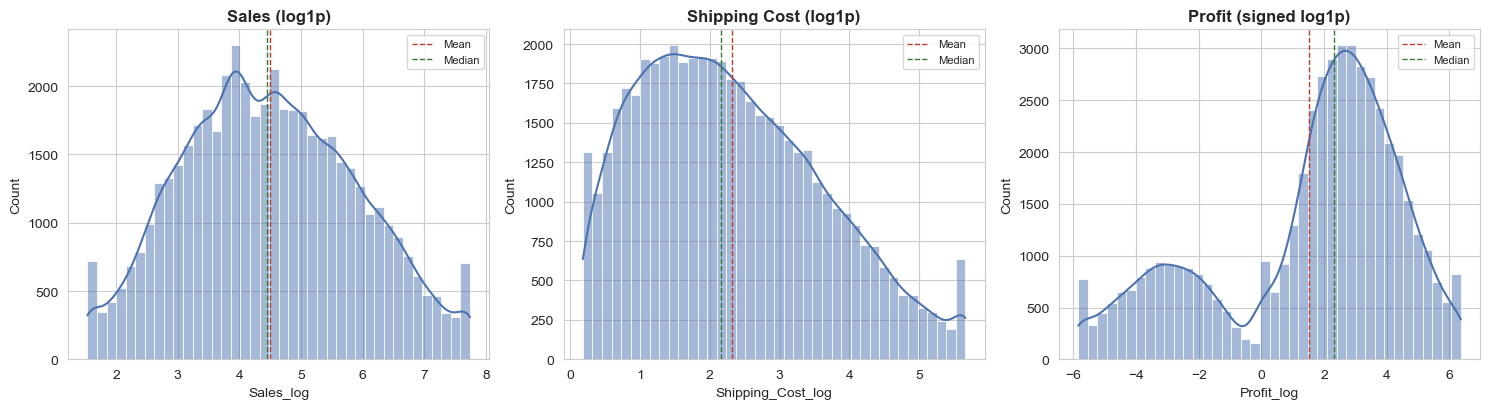

In [45]:

df_log = df_model.copy()
df_log["Sales_log"] = np.log1p(df_log["Sales"])
df_log["Shipping_Cost_log"] = np.log1p(df_log["Shipping Cost"])
df_log["Profit_log"] = np.sign(df_log["Profit"]) * np.log1p(np.abs(df_log["Profit"]))

log_cols = ["Sales_log", "Shipping_Cost_log", "Profit_log"]
titles = ["Sales (log1p)", "Shipping Cost (log1p)", "Profit (signed log1p)"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, col, title in zip(axes, log_cols, titles):
    sns.histplot(df_log[col], bins=40, kde=True, color=PRIMARY, ax=ax)
    ax.axvline(df_log[col].mean(), color=MEAN_COLOR, linestyle="--", linewidth=1, label="Mean")
    ax.axvline(df_log[col].median(), color=MEDIAN_COLOR, linestyle="--", linewidth=1, label="Median")
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


Profit_log was only used to check the distribution shape; the final model trains on the original Profit.

## 6. Final Data Preparation for Modeling

### 6.0 Convert Categorical Columns to Numbers (One-Hot Encoding)
Models only understand numbers, so we convert categorical columns (like Category or Region) into several 0/1 columns using `pd.get_dummies`.

We fit the dummy columns on `X_train` and reindex `X_test` onto the same columns, so a category that only appears in test can't silently create a column the model never trained on.

In [46]:
X_train_encoded = pd.get_dummies(X_train, columns=categorical_features, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_features, drop_first=True)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

print("Number of columns before encoding:", X_train.shape[1])
print("Number of columns after encoding:", X_train_encoded.shape[1])

X_train, X_test = X_train_encoded, X_test_encoded
X_train.head()

Number of columns before encoding: 51
Number of columns after encoding: 233


,Sales,Quantity,Discount,Shipping Cost,Returned,Order Month,Order Year,Order DayOfWeek,Shipping Duration,cust_order_count,...,Sub-Category_Envelopes,Sub-Category_Fasteners,Sub-Category_Furnishings,Sub-Category_Labels,Sub-Category_Machines,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables
0,579.450012,5,0.0,32.900002,0,8,2014,2,5,31,...,False,False,False,False,False,False,False,False,False,False
1,244.768005,4,0.2,64.519997,0,4,2012,2,4,69,...,False,False,False,False,False,False,True,False,False,False
2,21.719999,2,0.0,6.810000,0,8,2014,0,3,68,...,False,True,False,False,False,False,False,False,False,False
3,13.380000,1,0.0,1.880000,1,8,2013,4,4,69,...,False,True,False,False,False,False,False,False,False,False
4,13.110000,1,0.0,3.260000,0,8,2012,0,4,69,...,False,False,False,False,False,False,False,False,False,False


### 6.1 Train/Test Shapes
The split already happened back in 5.0.2 (before the aggregate features were built), so this is just a sanity check that both sets survived the encoding with the same columns.

In [ ]:
print("Train:", X_train.shape)
print("Test:", X_test.shape)


### 6.2 Comparing a Few Simple Scalers
We only scale the numeric columns (numeric_features); the columns that came from One-Hot Encoding (already 0s and 1s) don't need scaling.

We try three scalers: each time we fit the scaler on Train, only transform Test (so Test data doesn't leak), then build a quick LinearRegression and print the R² on Test.

In [48]:
scalers = {
    "Standard": StandardScaler(),
    "MinMax": MinMaxScaler(),
    "Robust": RobustScaler(),
}

scaler_scores = {}

for name, scaler in scalers.items():
    X_train_try = X_train.copy()
    X_test_try = X_test.copy()

    X_train_try[numeric_features] = scaler.fit_transform(X_train[numeric_features])
    X_test_try[numeric_features] = scaler.transform(X_test[numeric_features])

    quick_model = LinearRegression()
    quick_model.fit(X_train_try, y_train)

    test_r2 = quick_model.score(X_test_try, y_test)
    scaler_scores[name] = test_r2

    print(f"{name} Scaler -> Test R2: {test_r2:.4f}")

best_scaler_name = max(scaler_scores, key=scaler_scores.get)
print("\nbest Scaler:", best_scaler_name)


Standard Scaler -> Test R2: 0.6521
MinMax Scaler -> Test R2: 0.6521
Robust Scaler -> Test R2: 0.6521

best Scaler: MinMax


For tree-based models (Decision Tree, Random Forest) the choice of scaler doesn't matter much, but since all models use the same data, we keep the winning scaler for everything.

In [49]:
final_scaler = scalers[best_scaler_name]

X_train[numeric_features] = final_scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = final_scaler.transform(X_test[numeric_features])

print("number of columns:", X_train.shape[1])
X_train.head()


number of columns: 233


,Sales,Quantity,Discount,Shipping Cost,Returned,Order Month,Order Year,Order DayOfWeek,Shipping Duration,cust_order_count,...,Sub-Category_Envelopes,Sub-Category_Fasteners,Sub-Category_Furnishings,Sub-Category_Labels,Sub-Category_Machines,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables
0,0.250722,0.307692,0.000000,0.114237,0.0,0.636364,1.000000,0.333333,0.714286,0.147541,...,False,False,False,False,False,False,False,False,False,False
1,0.104993,0.230769,0.235294,0.224701,0.0,0.272727,0.333333,0.333333,0.571429,0.770492,...,False,False,False,False,False,False,True,False,False,False
2,0.007872,0.076923,0.000000,0.023092,0.0,0.636364,1.000000,0.000000,0.428571,0.754098,...,False,True,False,False,False,False,False,False,False,False
3,0.004241,0.000000,0.000000,0.005869,1.0,0.636364,0.666667,0.666667,0.571429,0.770492,...,False,True,False,False,False,False,False,False,False,False
4,0.004123,0.000000,0.000000,0.010690,0.0,0.636364,0.333333,0.000000,0.571429,0.770492,...,False,False,False,False,False,False,False,False,False,False


## 7. Modeling

### 7.1 Baseline Model

In [50]:
model_linear = LinearRegression()
model_linear.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### 7.2 Other Models

In [ ]:
X_tr_fit, X_val_fit, y_tr_fit, y_val_fit = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42
)

models_basic = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01, max_iter=3000),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=2000),

    "DecisionTree": DecisionTreeRegressor(
        max_depth=8,
        min_samples_leaf=4,
        random_state=42
    ),

    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=18,
        min_samples_leaf=4,
        max_features=0.5,
        random_state=42,
        n_jobs=-1
    ),

    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=600,
        max_depth=4,
        learning_rate=0.04,
        subsample=0.8,
        min_samples_leaf=5,
        validation_fraction=0.15,
        n_iter_no_change=20,
        tol=1e-4,
        random_state=42
    ),
}

trained_models = {}

for name, model in models_basic.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

print("Basic models trained.")


### 7.2.1 XGBoost Models
Separate cell because it takes the longest — this way it can be re-run on its own without retraining the fast models above.


In [ ]:
from xgboost import XGBRegressor

models_xgb = {
    "xgb_model": XGBRegressor(
        n_estimators=1500,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        reg_lambda=3,
        early_stopping_rounds=40,
        random_state=42,
        n_jobs=-1
    ),

    "xgb_model_reg": XGBRegressor(
        n_estimators=1500,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1.0,
        reg_lambda=5.0,
        min_child_weight=5,
        early_stopping_rounds=40,
        random_state=42,
        n_jobs=-1
    ),
}

for name, model in models_xgb.items():
    model.fit(X_tr_fit, y_tr_fit, eval_set=[(X_val_fit, y_val_fit)], verbose=False)
    trained_models[name] = model

print("XGBoost models trained.")


### 7.3 Polynomial Regression
Polynomial Regression needs its own input columns (degree-2 combinations of the numeric features), so it's built separately from the `models` loop above. We only expand the **numeric** columns (`numeric_features`) with `PolynomialFeatures` — expanding the one-hot columns too would explode the number of columns for no real benefit — then combine the result with the existing one-hot categorical columns.

In [ ]:
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly_num = poly.fit_transform(X_train[numeric_features])
X_test_poly_num = poly.transform(X_test[numeric_features])

poly_feature_names = poly.get_feature_names_out(numeric_features)

X_train_poly_num_df = pd.DataFrame(X_train_poly_num, columns=poly_feature_names, index=X_train.index)
X_test_poly_num_df = pd.DataFrame(X_test_poly_num, columns=poly_feature_names, index=X_test.index)

cat_cols = []
for col in X_train.columns:
    if col not in numeric_features:
        cat_cols.append(col)

X_train_poly = pd.concat([X_train_poly_num_df, X_train[cat_cols]], axis=1)
X_test_poly = pd.concat([X_test_poly_num_df, X_test[cat_cols]], axis=1)

print("Number of columns for Polynomial Regression:", X_train_poly.shape[1])

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)


### 7.4 CatBoost (native categorical handling)
Same idea as `ML_Q1.ipynb`: `MAE` loss (matches the metric we actually care about and is robust to the outliers we clipped but didn't remove), a high iteration count with early stopping so it stops exactly when the test score stalls, and categorical columns passed in natively via `cat_features` instead of being mean-encoded or one-hot'd. Needs `pip install catboost` if it isn't already available.

In [53]:
from catboost import CatBoostRegressor

catboost_model = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    loss_function="MAE",
    eval_metric="MAE",
    random_seed=42,
    verbose=200,
    early_stopping_rounds=200
)

catboost_model.fit(
    X_train_cb, y_train,
    cat_features=catboost_cat_cols,
    eval_set=(X_test_cb, y_test),
    use_best_model=True
)

0:	learn: 53.3926596	test: 51.3957110	best: 51.3957110 (0)	total: 169ms	remaining: 8m 28s
200:	learn: 24.9208667	test: 22.6301816	best: 22.6301816 (200)	total: 15.8s	remaining: 3m 39s
400:	learn: 23.5177589	test: 21.1817559	best: 21.1817559 (400)	total: 31.4s	remaining: 3m 23s
600:	learn: 22.8889784	test: 20.6949019	best: 20.6949019 (600)	total: 45.7s	remaining: 3m 2s
800:	learn: 22.4446027	test: 20.4604357	best: 20.4603390 (799)	total: 1m	remaining: 2m 44s
1000:	learn: 22.0710467	test: 20.2227013	best: 20.2227013 (1000)	total: 1m 13s	remaining: 2m 26s
1200:	learn: 21.7808928	test: 20.0875905	best: 20.0875905 (1200)	total: 1m 26s	remaining: 2m 9s
1400:	learn: 21.5077078	test: 19.9891818	best: 19.9886936 (1396)	total: 1m 40s	remaining: 1m 54s
1600:	learn: 21.2334913	test: 19.9085300	best: 19.9082427 (1597)	total: 1m 53s	remaining: 1m 38s
1800:	learn: 20.9731450	test: 19.8295155	best: 19.8295155 (1800)	total: 2m 6s	remaining: 1m 24s
2000:	learn: 20.7119217	test: 19.7080966	best: 19.70784

CatBoostRegressor(depth=6, early_stopping_rounds=200, eval_metric='MAE', iterations=3000, l2_leaf_reg=3, learning_rate=0.05, loss_function='MAE', random_seed=42, verbose=200)

## 8. Model Evaluation

In [54]:
def evaluate(model, X_tr, y_tr, X_te, y_te, name="model"):
    y_pred_train = model.predict(X_tr)
    y_pred_test = model.predict(X_te)

    return {
        "model": name,
        "train_MAE": mean_absolute_error(y_tr, y_pred_train),
        "test_MAE": mean_absolute_error(y_te, y_pred_test),
        "train_RMSE": np.sqrt(mean_squared_error(y_tr, y_pred_train)),
        "test_RMSE": np.sqrt(mean_squared_error(y_te, y_pred_test)),
        "train_R2": r2_score(y_tr, y_pred_train),
        "test_R2": r2_score(y_te, y_pred_test),
    }


In [55]:
results_list = []
results_list.append(
    evaluate(model_linear, X_train, y_train, X_test, y_test, "Linear Regression")
)

for name, model in trained_models.items():
    results_list.append(
        evaluate(model, X_train, y_train, X_test, y_test, name)
    )

results_list.append(
    evaluate(model_poly, X_train_poly, y_train, X_test_poly, y_test, "Polynomial Regression")
)

results_list.append(
    evaluate(catboost_model, X_train_cb, y_train, X_test_cb, y_test, "CatBoost")
)

results_df = pd.DataFrame(results_list)
results_df.round(4)


,model,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2
0,Linear Regression,33.6772,32.9256,63.6464,62.8151,0.6603,0.6521
1,Ridge,33.7852,33.0356,63.6861,62.8582,0.6598,0.6516
2,Lasso,33.6593,32.8402,63.7420,62.7232,0.6592,0.6531
3,ElasticNet,41.6514,40.7862,72.7114,72.0850,0.5566,0.5418
4,DecisionTree,27.2793,29.2790,54.5456,63.0976,0.7505,0.6490
5,RandomForest,17.0387,27.8691,34.6723,58.6224,0.8992,0.6970
6,GradientBoosting,24.7882,27.4429,45.6894,55.4059,0.8249,0.7293
7,xgb_model,23.5842,27.3341,43.3001,55.7256,0.8428,0.7262
8,xgb_model_reg,25.3988,27.8747,47.5788,56.5915,0.8101,0.7176
9,Polynomial Regression,30.9934,32.4798,57.8986,62.4385,0.7188,0.6562


### 8.0 Visual Comparison of Test Results
The table above already has the numbers; this chart just makes it easier to compare the models with the eye — Test R² (higher is better) and Test MAE (lower is better) side by side.

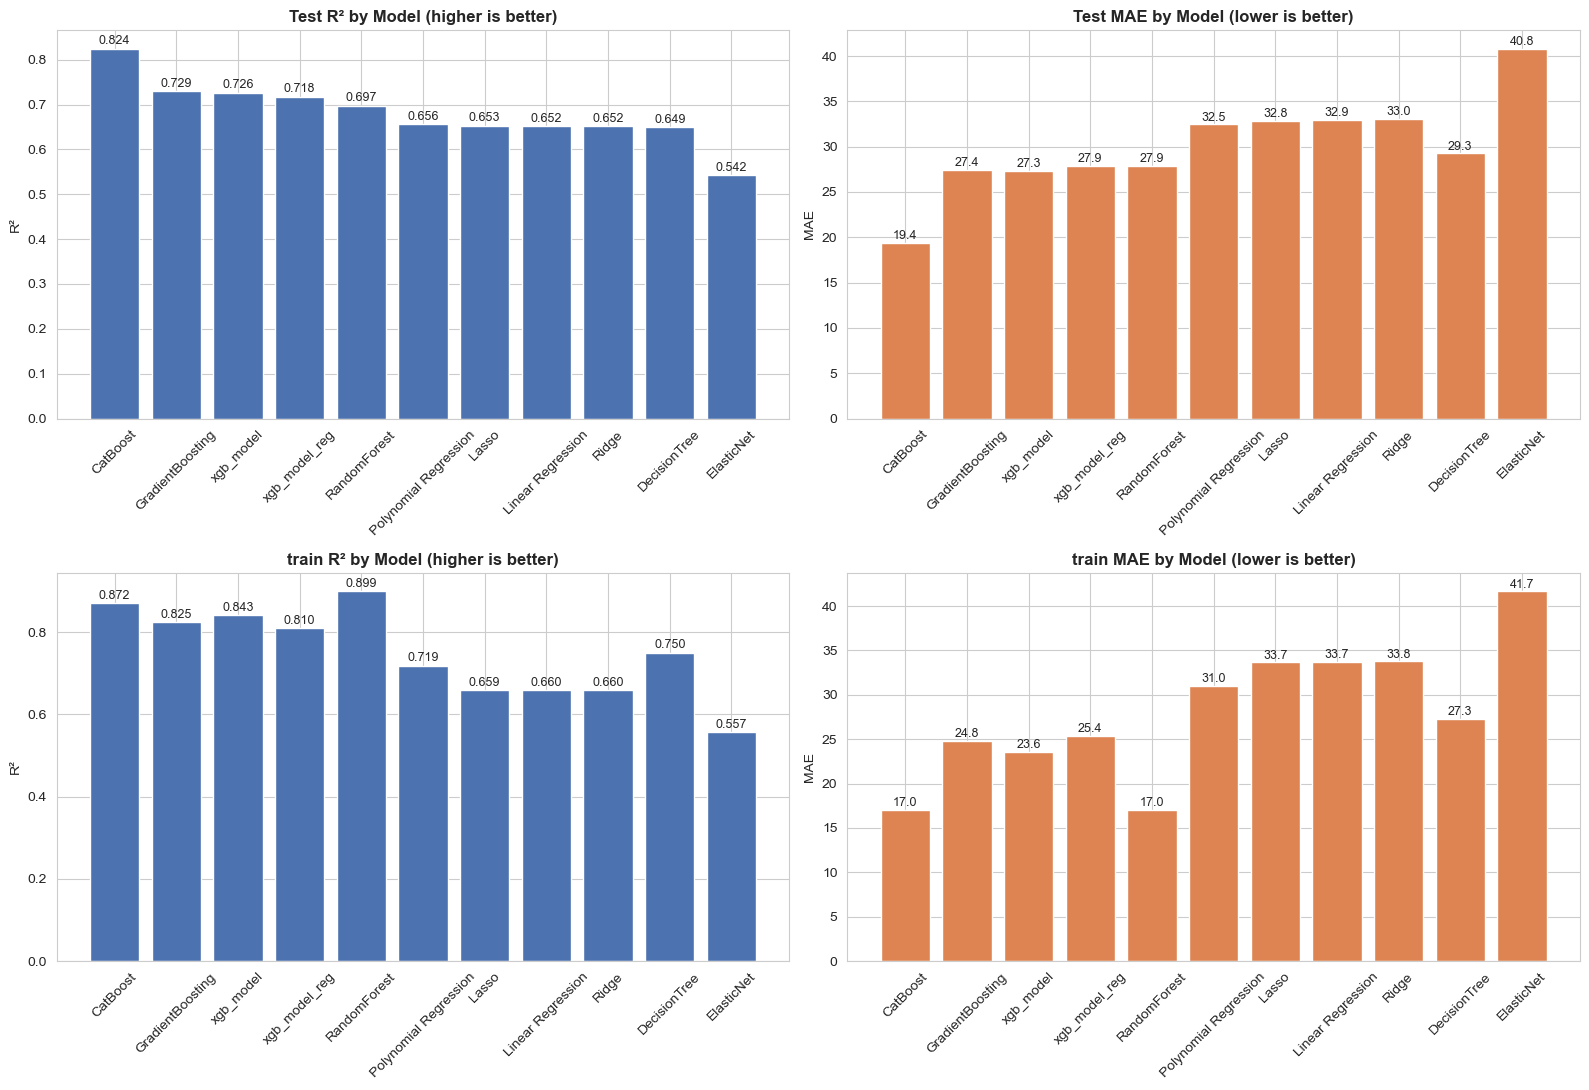

In [56]:
fig, axes = plt.subplots(2, 2,figsize=(16,11))
axes = axes.flatten() 
plot_df = results_df.sort_values("test_R2", ascending=False)

axes[0].bar(plot_df["model"], plot_df["test_R2"], color=PRIMARY)
axes[0].set_title("Test R\u00b2 by Model (higher is better)")
axes[0].set_ylabel("R\u00b2")
axes[0].tick_params(axis="x", rotation=45)
for i, v in enumerate(plot_df["test_R2"]):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

axes[1].bar(plot_df["model"], plot_df["test_MAE"], color=SECONDARY)
axes[1].set_title("Test MAE by Model (lower is better)")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=45)
for i, v in enumerate(plot_df["test_MAE"]):
    axes[1].text(i, v + plot_df["test_MAE"].max() * 0.01, f"{v:.1f}", ha="center", fontsize=9)

axes[2].bar(plot_df["model"], plot_df["train_R2"], color=PRIMARY)
axes[2].set_title("train R\u00b2 by Model (higher is better)")
axes[2].set_ylabel("R\u00b2")
axes[2].tick_params(axis="x", rotation=45)
for i, v in enumerate(plot_df["train_R2"]):
    axes[2].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

axes[3].bar(plot_df["model"], plot_df["train_MAE"], color=SECONDARY)
axes[3].set_title("train MAE by Model (lower is better)")
axes[3].set_ylabel("MAE")
axes[3].tick_params(axis="x", rotation=45)
for i, v in enumerate(plot_df["train_MAE"]):
    axes[3].text(i, v + plot_df["train_MAE"].max() * 0.01, f"{v:.1f}", ha="center", fontsize=9)



plt.tight_layout()
plt.show()


### 8.1 Checking Overfitting via the Train/Test Gap

In [57]:
results_df["R2_gap"] = results_df["train_R2"] - results_df["test_R2"]
results_df[["model", "train_R2", "test_R2", "R2_gap"]].sort_values("test_R2", ascending=False).round(4)

,model,train_R2,test_R2,R2_gap
10,CatBoost,0.8717,0.8239,0.0477
6,GradientBoosting,0.8249,0.7293,0.0956
7,xgb_model,0.8428,0.7262,0.1166
8,xgb_model_reg,0.8101,0.7176,0.0925
5,RandomForest,0.8992,0.6970,0.2022
9,Polynomial Regression,0.7188,0.6562,0.0626
2,Lasso,0.6592,0.6531,0.0061
0,Linear Regression,0.6603,0.6521,0.0082
1,Ridge,0.6598,0.6516,0.0082
4,DecisionTree,0.7505,0.6490,0.1015


The deeper Random Forest gets, the bigger the Train/Test gap becomes. That's why we keep the depth limited.

## 9. Hyperparameter Tuning


### 9.1 Grid Search for Polynomial Regression


In [58]:
degree_options = [2, 3]
alpha_options = [0.1, 1.0, 10.0]

poly_results = []
poly_models = {}   

for degree in degree_options:
    poly_d = PolynomialFeatures(degree=degree, include_bias=False)

    X_train_poly_num_d = poly_d.fit_transform(X_train[numeric_features])
    X_test_poly_num_d = poly_d.transform(X_test[numeric_features])

    poly_feature_names_d = poly_d.get_feature_names_out(numeric_features)
    X_train_poly_num_df_d = pd.DataFrame(X_train_poly_num_d, columns=poly_feature_names_d, index=X_train.index)
    X_test_poly_num_df_d = pd.DataFrame(X_test_poly_num_d, columns=poly_feature_names_d, index=X_test.index)

    X_train_poly_d = pd.concat([X_train_poly_num_df_d, X_train[cat_cols]], axis=1)
    X_test_poly_d = pd.concat([X_test_poly_num_df_d, X_test[cat_cols]], axis=1)

    for alpha in alpha_options:
        name = f"Poly(degree={degree}, alpha={alpha})"

        model = Ridge(alpha=alpha)
        model.fit(X_train_poly_d, y_train)

        result = evaluate(model, X_train_poly_d, y_train, X_test_poly_d, y_test, name)
        poly_results.append(result)
        poly_models[name] = {"model": model, "X_train": X_train_poly_d, "X_test": X_test_poly_d}

poly_results_df = pd.DataFrame(poly_results)
poly_results_df["R2_gap"] = poly_results_df["train_R2"] - poly_results_df["test_R2"]
poly_results_df.sort_values("test_R2", ascending=False).round(4)

,model,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2,R2_gap
2,"Poly(degree=2, alpha=10.0)",31.2703,31.5948,59.7677,60.9399,0.7004,0.6726,0.0279
1,"Poly(degree=2, alpha=1.0)",31.0273,31.7979,58.8137,61.2940,0.7099,0.6687,0.0412
0,"Poly(degree=2, alpha=0.1)",31.0615,32.0615,58.4755,61.6790,0.7132,0.6646,0.0487
5,"Poly(degree=3, alpha=10.0)",29.2098,32.1952,54.3212,62.4512,0.7525,0.6561,0.0964
4,"Poly(degree=3, alpha=1.0)",27.9419,35.0178,48.9502,66.3849,0.7990,0.6114,0.1876
3,"Poly(degree=3, alpha=0.1)",26.4837,39.5768,43.5091,75.3240,0.8412,0.4997,0.3415


In [59]:
best_poly_name = poly_results_df.sort_values("test_R2", ascending=False).iloc[0]["model"]
best_poly_result = [r for r in poly_results if r["model"] == best_poly_name][0]

best_poly = poly_models[best_poly_name]["model"]
best_poly_X_train = poly_models[best_poly_name]["X_train"]
best_poly_X_test = poly_models[best_poly_name]["X_test"]

print("Best Polynomial setup:", best_poly_name)
pd.DataFrame([best_poly_result]).round(4)

Best Polynomial setup: Poly(degree=2, alpha=10.0)


,model,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2
0,"Poly(degree=2, alpha=10.0)",31.2703,31.5948,59.7677,60.9399,0.7004,0.6726


### 9.2 Select the Top 2 Models (from the evaluate results)
The Section 8 `evaluate` results can change every time the notebook is re-run (different features, different train/test split, etc.), so the two "best" models are not always the same ones. Instead of hard-coding two model names here, we pick the top 2 automatically from `results_df`, using the tuned Polynomial Regression result from 9.1 instead of the untuned one.


In [ ]:
poly_row = pd.DataFrame([best_poly_result])
poly_row["model"] = "Polynomial Regression (Tuned)"

baseline_rows = results_df[results_df["model"] != "Polynomial Regression"]
all_results = pd.concat([baseline_rows, poly_row], ignore_index=True)

top2 = all_results.sort_values("test_R2", ascending=False).head(2)
print(top2[["model", "test_R2"]])

model_registry = {}
model_registry["Linear Regression"] = (model_linear, X_train, X_test)
model_registry["CatBoost"] = (catboost_model, X_train_cb, X_test_cb)
model_registry["Polynomial Regression (Tuned)"] = (best_poly, best_poly_X_train, best_poly_X_test)

for name in trained_models:
    model_registry[name] = (trained_models[name], X_train, X_test)


### 9.3 Cross Validation (5-Fold) for the Top 2 Models
Only one cross-validation run (5-fold) per model now, only for the 2 models picked above — instead of running both 3-fold and 5-fold for two hard-coded models like before. This cuts the CV time roughly in half.


In [ ]:
cv_results = {}

for name in top2["model"]:
    model, X_tr, X_te = model_registry[name]
    model_cv = clone(model)

    model_params = model_cv.get_params()

    if model_params.get("early_stopping_rounds"):
        model_cv.set_params(early_stopping_rounds=None)

    if "verbose" in model_params:
        model_cv.set_params(verbose=False)

    if name == "CatBoost":
        model_cv.set_params(cat_features=catboost_cat_cols)

    scores = cross_val_score(model_cv, X_tr, y_train, cv=5, scoring="r2")
    cv_results[name] = scores

    print(name, "- CV scores:", scores)
    print(name, "- average R2:", round(scores.mean(), 4))


### 9.4 Final Comparison (Test Score + CV Score for the Top 2 Models)


In [ ]:
cv_means = []
for name in top2["model"]:
    cv_means.append(round(cv_results[name].mean(), 4))

final_results = top2.copy()
final_results["CV_R2_mean"] = cv_means
final_results["R2_gap"] = final_results["train_R2"] - final_results["test_R2"]
final_results.round(4)


Compare the rows above: the final model should be whichever row has the best `test_R2` **and** a reasonably small `R2_gap` (a huge gap means it memorized the training data instead of learning a general pattern).


### 9.5 Picking the Final Model


In [ ]:
final_results_sorted = final_results.sort_values("test_R2", ascending=False)
best_name = final_results_sorted.iloc[0]["model"]

final_model, final_X_train, final_X_test = model_registry[best_name]
final_model_name = best_name

print("Final model:", final_model_name)
print("Test R2:", round(final_results_sorted.iloc[0]["test_R2"], 4))


### 10.2 Actual vs Predicted Plot

In [ ]:
y_pred = final_model.predict(final_X_test)
r2 = r2_score(y_test, y_pred)

plt.figure(figsize=(6.5, 6.5))
plt.scatter(y_test, y_pred, alpha=0.25, s=15, color=PRIMARY, edgecolor="none")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", label="Perfect Prediction")
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted Profit")
plt.text(0.05, 0.92, f"R² = {r2:.3f}", transform=plt.gca().transAxes,
          fontsize=11, bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()


### 10.3 Error Analysis

In [ ]:
residuals = y_test - y_pred
res_mean, res_std = residuals.mean(), residuals.std()

plt.figure(figsize=(8.5, 4.2))
sns.histplot(residuals, bins=50, kde=True, color=PRIMARY)
plt.axvline(0, color="black", linestyle="-", linewidth=1)
plt.axvline(res_mean, color=MEAN_COLOR, linestyle="--", label=f"Mean = {res_mean:.2f}")
plt.title(f"Residual Distribution (std ≈ {res_std:.2f})")
plt.xlabel("Error (Actual - Predicted)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [ ]:
prediction_df = pd.DataFrame({
    "Actual Profit": y_test,
    "Predicted Profit": y_pred,
    "Error": y_test - y_pred
})

prediction_df.head(10)